Target time: 0.9 ns = 900000 fs
PE_A1: D replicas = [2.51783630e-09 3.40820722e-09 2.73183833e-09] (m^2/s)
PE_A2: D replicas = [2.30137426e-09 3.05169926e-09 2.54270444e-09] (m^2/s)
PE_P1: D replicas = [3.13579037e-09 4.25405056e-09 2.96567815e-09] (m^2/s)
PE_P2: D replicas = [3.83234593e-09 3.83234593e-09 3.83234593e-09] (m^2/s)

Summary (m^2/s):
  system    D_mean_m2s     D_std_m2s  n_replicas
0  PE_A1  2.885961e-09  4.647638e-10           3
1  PE_A2  2.631926e-09  3.830369e-10           3
2  PE_P1  3.451840e-09  6.999223e-10           3
3  PE_P2  3.832346e-09  0.000000e+00           3

Saved: Diffusion_at_0p9ns_ACS.png
Saved: Diffusion_at_0p9ns_ACS.pdf
Saved: Diffusion_at_0p9ns_summary.csv


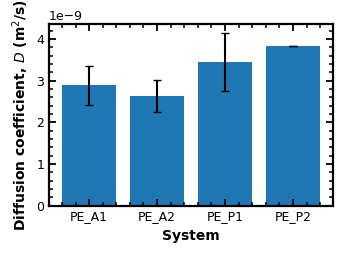

In [8]:
#!/usr/bin/env python3
"""
Compute diffusion coefficient at t = 0.9 ns from MSD using:
  MSD = 6 * D * t

- Each system has 3 replica CSV files.
- Time is in femtoseconds (fs) (or "timestep" steps with DT_FS fs/step).
- MSD is the LAST column in each CSV (Å^2).
- Output D in m^2/s.
- Then average across replicas (mean ± std) and plot (ACS-like style) with error bars.
"""

import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# -----------------------------
# USER SETTINGS
# -----------------------------
# Put your CSV paths here (3 replicas per system)
SYSTEM_FILES = {
    "PE_A1": [
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/MSD_Analysis/A1_with_timestep_Replica1_type10_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/MSD_Analysis/A1_with_timestep_Replica2_type10_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/MSD_Analysis/A1_with_timestep_Replica3_type10_mean_squared_terms.csv",
    ],
    "PE_A2": [
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/MSD_Analysis/A2_with_timestep_Replica1_type9_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/MSD_Analysis/A2_with_timestep_Replica2_type9_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_A2/MSD_Analysis/A2_with_timestep_Replica3_type9_mean_squared_terms.csv",
    ],
    "PE_P1": [
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/MSD_Analysis/P1_with_timestep_Replica1_type10_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/MSD_Analysis/P1_with_timestep_Replica2_type10_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/MSD_Analysis/P1_with_timestep_Replica3_type10_mean_squared_terms.csv",
    ],
    "PE_P2": [
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/MSD_Analysis/P2_with_timestep_Replica1_type9_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/MSD_Analysis/P2_with_timestep_Replica1_type9_mean_squared_terms.csv",
        "/blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2/MSD_Analysis/P2_with_timestep_Replica1_type9_mean_squared_terms.csv",
    ],
}

# If your first column is "timestep" in STEPS (not fs), set this to your timestep in fs/step.
# If your "timestep" column is already in fs, leaving DT_FS = 1.0 is correct.
DT_FS = 1.0

TARGET_NS = 0.9  # diffusion evaluated at 0.9 ns

OUT_PNG = "Diffusion_at_0p9ns_ACS.png"
OUT_PDF = "Diffusion_at_0p9ns_ACS.pdf"

# -----------------------------
# CONSTANTS / CONVERSIONS
# -----------------------------
ANG2_TO_M2 = 1e-20   # (1 Å)^2 = 1e-20 m^2
FS_TO_S    = 1e-15   # 1 fs = 1e-15 s


def read_csv_time_msd(path: str, dt_fs: float = 1.0):
    """
    Reads a CSV with headers.
    - Time column is assumed to be named 'timestep' (as in your screenshot).
      We convert it to time_fs = timestep * dt_fs.
    - MSD column is assumed to be the LAST column of the CSV.
    Returns:
      t_fs (numpy array), msd_A2 (numpy array), msd_col_name (str)
    """
    df = pd.read_csv(path)

    if "timestep" not in df.columns:
        raise ValueError(
            f"[{path}] Expected a 'timestep' column, but found: {list(df.columns)}"
        )

    # MSD is last column
    msd_col = df.columns[-1]

    # Convert to numeric safely
    t_raw = pd.to_numeric(df["timestep"], errors="coerce")
    msd = pd.to_numeric(df[msd_col], errors="coerce")

    # Drop rows with NaNs
    good = ~(t_raw.isna() | msd.isna())
    t_raw = t_raw[good].to_numpy(dtype=float)
    msd = msd[good].to_numpy(dtype=float)

    # Convert "timestep" to fs
    t_fs = t_raw * float(dt_fs)

    # Sort by time (just in case)
    order = np.argsort(t_fs)
    t_fs = t_fs[order]
    msd = msd[order]

    return t_fs, msd, msd_col


def msd_at_target_time(t_fs: np.ndarray, msd_A2: np.ndarray, target_fs: float):
    """
    Linear interpolation of MSD at target time.
    If target is outside range, raises an error.
    """
    if target_fs < t_fs.min() or target_fs > t_fs.max():
        raise ValueError(
            f"Target time {target_fs:.1f} fs is outside data range "
            f"[{t_fs.min():.1f}, {t_fs.max():.1f}] fs"
        )
    return float(np.interp(target_fs, t_fs, msd_A2))


def diffusion_from_msd(msd_A2: float, t_fs: float) -> float:
    """
    D = MSD / (6 t)
    Convert: MSD Å^2 -> m^2, fs -> s
    """
    msd_m2 = msd_A2 * ANG2_TO_M2
    t_s = t_fs * FS_TO_S
    return msd_m2 / (6.0 * t_s)


def compute_system_Ds(system_files: list[str], target_fs: float, dt_fs: float):
    """
    Returns list of D values (one per replica) for a system.
    """
    D_list = []
    for p in system_files:
        t_fs, msd_A2, msd_col = read_csv_time_msd(p, dt_fs=dt_fs)
        msd_target = msd_at_target_time(t_fs, msd_A2, target_fs)
        D = diffusion_from_msd(msd_target, target_fs)
        D_list.append(D)
    return np.array(D_list, dtype=float)


def acs_style():
    """
    ACS-like clean styling: consistent fonts, inward ticks, thicker borders.
    """
    mpl.rcParams.update({
        "font.family": "DejaVu Sans",   # change to "Arial" if you have it installed
        "font.size": 9,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 8,
        "axes.linewidth": 1.6,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.width": 1.3,
        "ytick.major.width": 1.3,
        "xtick.minor.width": 1.1,
        "ytick.minor.width": 1.1,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "axes.spines.top": True,
        "axes.spines.right": True,
        "savefig.dpi": 600,
    })


def main():
    target_fs = TARGET_NS * 1e6  # 0.9 ns -> 900,000 fs
    print(f"Target time: {TARGET_NS} ns = {target_fs:.0f} fs")

    rows = []
    for sys_name, files in SYSTEM_FILES.items():
        Ds = compute_system_Ds(files, target_fs=target_fs, dt_fs=DT_FS)
        rows.append({
            "system": sys_name,
            "D_mean_m2s": float(np.mean(Ds)),
            "D_std_m2s": float(np.std(Ds, ddof=1)) if len(Ds) > 1 else 0.0,
            "n_replicas": len(Ds),
        })
        print(f"{sys_name}: D replicas = {Ds} (m^2/s)")

    out = pd.DataFrame(rows).sort_values("system").reset_index(drop=True)
    print("\nSummary (m^2/s):")
    print(out)

    # ---- Plot ----
    acs_style()

    fig, ax = plt.subplots(figsize=(3.5, 2.6))  # ~single-column ACS-ish

    x = np.arange(len(out))
    y = out["D_mean_m2s"].to_numpy()
    yerr = out["D_std_m2s"].to_numpy()

    ax.bar(x, y, yerr=yerr, capsize=3, linewidth=0.0)

    ax.set_xticks(x)
    ax.set_xticklabels(out["system"].tolist(), rotation=0)

    ax.set_ylabel(r"Diffusion coefficient, $D$ (m$^2$/s)")
    ax.set_xlabel("System")

    ax.tick_params(which="both", top=True, right=True)
    ax.minorticks_on()

    # Keep plot clean: no title, no legend needed for bars
    fig.tight_layout()

    fig.savefig(OUT_PNG, bbox_inches="tight")
    fig.savefig(OUT_PDF, bbox_inches="tight")
    print(f"\nSaved: {OUT_PNG}")
    print(f"Saved: {OUT_PDF}")

    # Save table too (handy for paper)
    out.to_csv("Diffusion_at_0p9ns_summary.csv", index=False)
    print("Saved: Diffusion_at_0p9ns_summary.csv")


if __name__ == "__main__":
    main()

In [10]:
import pandas as pd

# Data extracted from the figure
data = {
    "system": ["PE-A1", "PE-A2", "PE-P1", "PE-P2"],
    "D_mean_m2s": [1.0e-9, 1.1e-9, 3.8e-10, 8.0e-10],
    "D_std_m2s": [0, 0, 0, 0]
}

# Create dataframe
df = pd.DataFrame(data)

# Save CSV
df.to_csv("experimental_diffusion.csv", index=False)

print("CSV file 'experimental_diffusion.csv' created successfully.")

CSV file 'experimental_diffusion.csv' created successfully.


In [ ]:
# Define the data in a list of dictionaries
data = [
    {"system": "TFP-25", "D (OH)": 2.26E-10, "D (water)": 8.08E-10, "OH std": 1.82519E-11, "wr std": 6.24819E-11},
    {"system": "TFP-33", "D (OH)": 2.92E-10, "D (water)": 9.83E-10, "OH std": 1.54554E-11, "wr std": 3.72317E-11},
    {"system": "PE-A1", "D (OH)": 9.23E-11, "D (water)": 3.35E-10, "OH std": 5.47015E-12, "wr std": 9.29598E-12},
    {"system": "PE-A2", "D (OH)": 1.32E-10, "D (water)": 4.73E-10, "OH std": 4.38129E-12, "wr std": 1.23408E-11},
    {"system": "PE-P1", "D (OH)": 2.81E-12, "D (water)": 1.95E-11, "OH std": 2.70277E-13, "wr std": 1.22544E-12},
    {"system": "PE-P2", "D (OH)": 1.52E-11, "D (water)": 1.52E-11, "OH std": 1.04789E-12, "wr std": 1.77004E-12},
    {"system": "PP-T", "D (OH)": 2.92E-12, "D (water)": 2.28E-11, "OH std": 4.93873E-13, "wr std": 3.93979E-12},
    {"system": "PP-D", "D (OH)": 1.65E-11, "D (water)": 1.05E-10, "OH std": 1.45828E-12, "wr std": 1.03571E-11}
]

# Create a DataFrame from the data
otmi_data = pd.DataFrame(data)

Std values feeding the error bars:
System           S1           S2
 PE-A1 5.470150e-12 4.647638e-10
 PE-A2 4.381290e-12 3.830369e-10
 PE-P1 2.702770e-13 6.999223e-10
 PE-P2 1.047890e-12 0.000000e+00


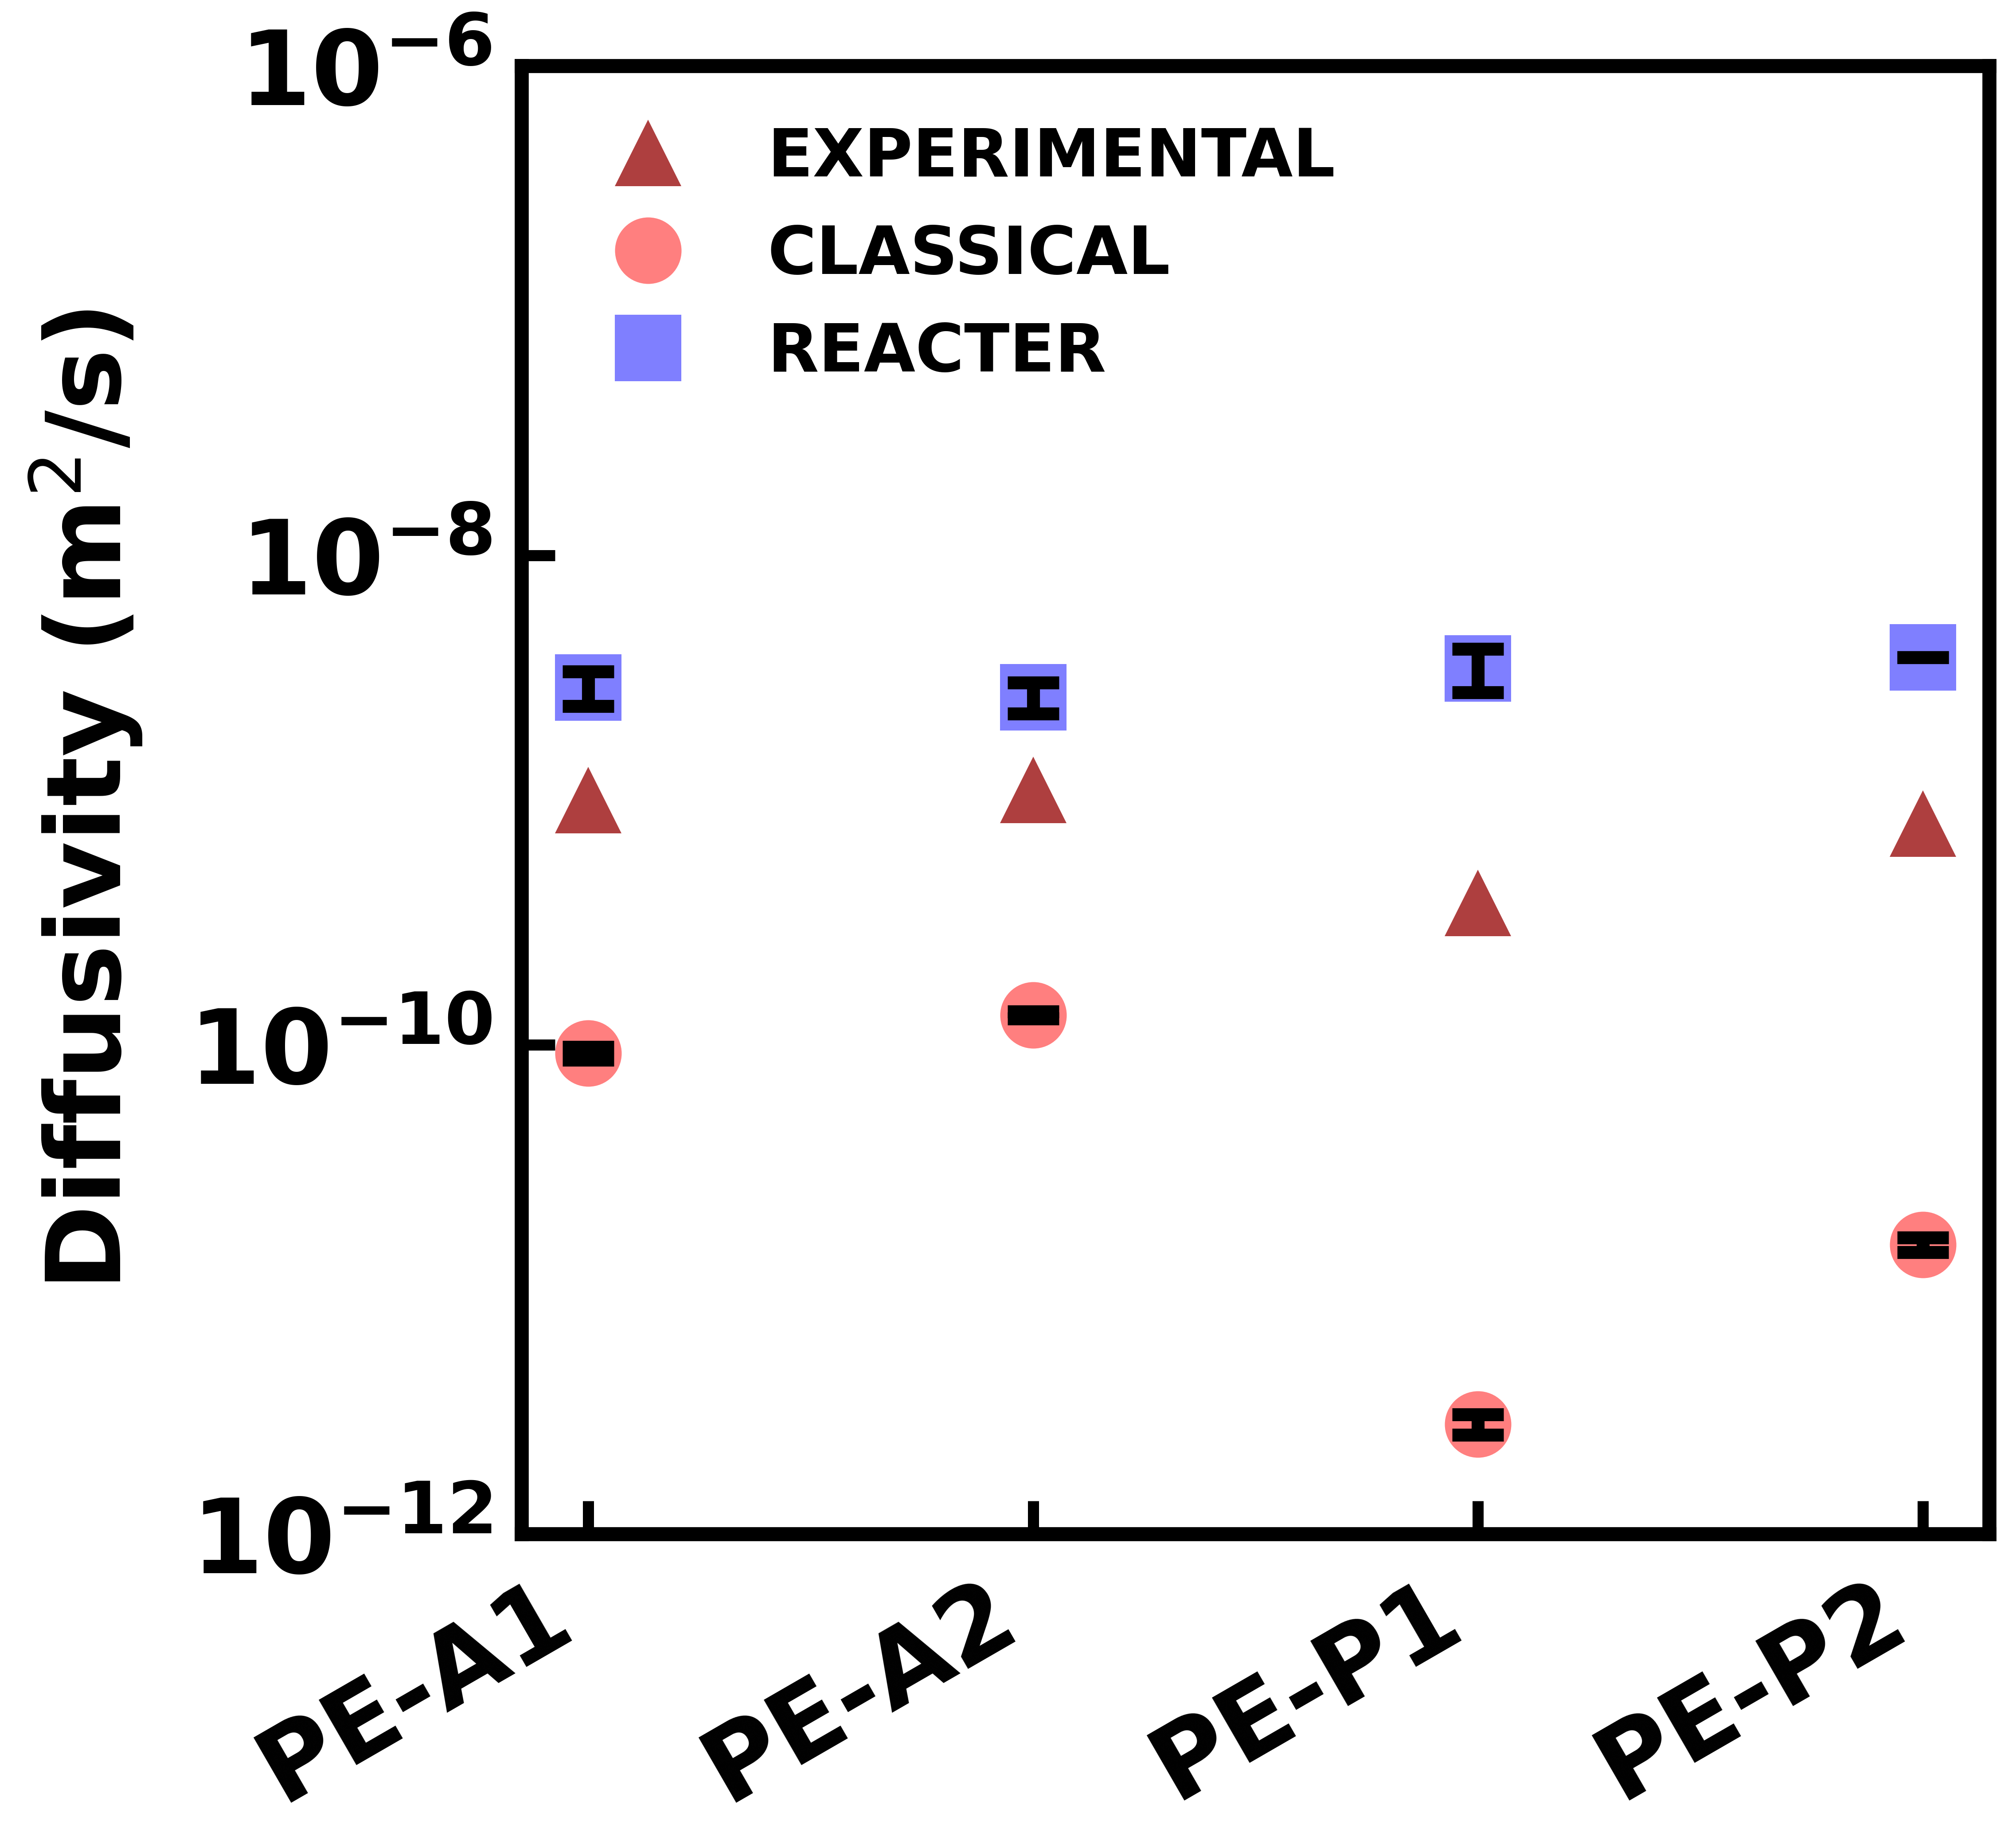

In [7]:
#!/usr/bin/env python3
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# FILES
# =========================
CSV1 = "CLASSICAL_updated.csv"
CSV2 = "updated_REACTER.csv"
CSV3 = "experimental_diffusion.csv"

LABEL1 = "CLASSICAL"
LABEL2 = "REACTER"
LABEL3 = "EXPERIMENTAL"

OUT_PNG = "diffusion_compare_fixed_merge_1.png"
OUT_PDF = "diffusion_compare_fixed_merge_1.pdf"

HEADER = 0

# =========================
# ACS STYLE
# =========================
LABEL_SIZE = 28
TICK_SIZE = 28
LEGEND_SIZE = 18

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": LABEL_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "axes.labelweight": "bold",
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
})

# =========================
# MARKER APPEARANCE CONTROLS
# =========================
MARKER_SIZE = 18         # marker size
FACE_ALPHA  = 0.5        # 1 = solid colourful faces (0 = invisible)
EDGE_WIDTH  = 0.0        # 0 = no outline on markers

# error-bar styling (black + thick)
EBAR_COLOR  = "black"
EBAR_WIDTH  = 3.5        # thickness of the error-bar lines
EBAR_CAP    = 3.5        # thickness of the error-bar caps
EBAR_CAPSIZE = 7

# =========================
# HELPERS
# =========================
def normalize_system_name(s):

    if pd.isna(s):
        return np.nan

    s = str(s).strip().upper()
    s = s.replace("_", "-").replace(" ", "")

    mapping = {
        "PEA1": "PE-A1",
        "PEA2": "PE-A2",
        "PEP1": "PE-P1",
        "PEP2": "PE-P2",
        "PE-A1": "PE-A1",
        "PE-A2": "PE-A2",
        "PE-P1": "PE-P1",
        "PE-P2": "PE-P2",
        "A1": "PE-A1",
        "A2": "PE-A2",
        "P1": "PE-P1",
        "P2": "PE-P2",
    }

    s2 = s.replace("-", "")

    if s in mapping:
        return mapping[s]

    if s2 in mapping:
        return mapping[s2]

    return s


def parse_std(val):

    if pd.isna(val):
        return np.nan

    s = str(val).strip()
    s = s.replace("+/-", "±").replace("+-", "±")
    s = s.replace("(", " ").replace(")", " ")
    s = re.sub(r"\s+", " ", s)

    if "±" in s:
        right = s.split("±", 1)[1]
        m = re.search(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", right)
        return float(m.group(0)) if m else np.nan

    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)

    if len(nums) >= 2:
        return float(nums[1])

    return np.nan


def load_diff_csv(path):

    df = pd.read_csv(path, header=HEADER)
    df = df.iloc[:, :3].copy()

    df.columns = ["System_raw", "Diffusion", "Mean_pm_Std"]

    df["System"] = df["System_raw"].apply(normalize_system_name)

    df["Diffusion"] = pd.to_numeric(df["Diffusion"], errors="coerce")

    df["Std"] = pd.to_numeric(df["Mean_pm_Std"], errors="coerce")

    mask = df["Std"].isna() & df["Mean_pm_Std"].notna()

    df.loc[mask, "Std"] = df.loc[mask, "Mean_pm_Std"].apply(parse_std)

    df = df.dropna(subset=["System", "Diffusion"]).copy()

    df = df.drop_duplicates(subset=["System"], keep="first")

    return df[["System", "Diffusion", "Std"]]


# =========================
# LOAD DATA
# =========================
d1 = load_diff_csv(CSV1).rename(columns={"Diffusion": "D1", "Std": "S1"})
d2 = load_diff_csv(CSV2).rename(columns={"Diffusion": "D2", "Std": "S2"})
d3 = load_diff_csv(CSV3).rename(columns={"Diffusion": "D3", "Std": "S3"})

# =========================
# MERGE
# =========================
m = pd.merge(d1, d2, on="System", how="inner")
m = pd.merge(m, d3, on="System", how="inner")

if m.empty:
    raise ValueError("No matching system names found among CSV files.")

preferred_order = ["PE-A1", "PE-A2", "PE-P1", "PE-P2"]

m["__order__"] = m["System"].apply(
    lambda s: preferred_order.index(s) if s in preferred_order else 999
)

m = m.sort_values("__order__").drop(columns="__order__").reset_index(drop=True)

systems = m["System"].tolist()

# Diagnostic: show the std values that drive the error bars.
# If S1/S2 are NaN or ~0, the bars will be invisible because the data has no spread.
print("Std values feeding the error bars:")
print(m[["System", "S1", "S2"]].to_string(index=False))

x = np.arange(len(systems), dtype=float)

# =========================
# ERROR BAR CONTROL
# =========================
MIN_DISPLAY_YERR = 0.0

S1_plot = m["S1"].to_numpy(dtype=float)
S2_plot = m["S2"].to_numpy(dtype=float)

if MIN_DISPLAY_YERR > 0:
    S1_plot = np.where(np.isfinite(S1_plot),
                       np.maximum(S1_plot, MIN_DISPLAY_YERR),
                       S1_plot)

    S2_plot = np.where(np.isfinite(S2_plot),
                       np.maximum(S2_plot, MIN_DISPLAY_YERR),
                       S2_plot)

# =========================
# COLORS (solid + transparent faces)
# =========================
# Colourful, distinct color per series
C_exp = "brown"
C_cls = "red"
C_rea = "blue"

face_exp = mcolors.to_rgba(C_exp, 0.9)
face_cls = mcolors.to_rgba(C_cls, FACE_ALPHA)
face_rea = mcolors.to_rgba(C_rea, FACE_ALPHA)

# no outline on the markers
EDGE_COLOR = "none"

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(8.2, 8.2), dpi=600)

D1 = m["D1"].to_numpy(dtype=float)
D2 = m["D2"].to_numpy(dtype=float)
D3 = m["D3"].to_numpy(dtype=float)


def log_safe_yerr(y, err):
    """Return [lower, upper] errors so the lower cap never reaches <= 0 on a log axis."""
    y = np.asarray(y, dtype=float)
    err = np.asarray(err, dtype=float)
    err = np.where(np.isfinite(err), err, 0.0)
    lower = np.minimum(err, y * 0.999999)   # keep lower cap strictly above zero
    upper = err
    return np.vstack([lower, upper])


# ---- 1) MARKERS (drawn underneath, low zorder) ----
ax.plot(
    x, D3, "^",
    markersize=MARKER_SIZE, markerfacecolor=face_exp,
    markeredgecolor=EDGE_COLOR, markeredgewidth=EDGE_WIDTH,
    linestyle="none", label=LABEL3, zorder=3
)
ax.plot(
    x, D1, "o",
    markersize=MARKER_SIZE, markerfacecolor=face_cls,
    markeredgecolor=EDGE_COLOR, markeredgewidth=EDGE_WIDTH,
    linestyle="none", label=LABEL1, zorder=3
)
ax.plot(
    x, D2, "s",
    markersize=MARKER_SIZE, markerfacecolor=face_rea,
    markeredgecolor=EDGE_COLOR, markeredgewidth=EDGE_WIDTH,
    linestyle="none", label=LABEL2, zorder=3
)

# ---- 2) ERROR BARS (black, thick, drawn ON TOP of the markers) ----
# EXPERIMENTAL (D3) has no std data -> no bars, unchanged
ax.errorbar(
    x, D1, yerr=log_safe_yerr(D1, S1_plot),
    fmt="none", ecolor=EBAR_COLOR,
    elinewidth=EBAR_WIDTH, capsize=EBAR_CAPSIZE, capthick=EBAR_CAP,
    zorder=10
)
ax.errorbar(
    x, D2, yerr=log_safe_yerr(D2, S2_plot),
    fmt="none", ecolor=EBAR_COLOR,
    elinewidth=EBAR_WIDTH, capsize=EBAR_CAPSIZE, capthick=EBAR_CAP,
    zorder=10
)

# =========================
# AXES
# =========================
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=30, ha="right")
ax.set_ylabel(
    r"Diffusivity (m$^2$/s)",
    fontsize=LABEL_SIZE,
    fontweight="bold",
    labelpad=12
)

ax.set_yscale("log")
ax.set_ylim(1e-12, 1e-6)
ax.set_yticks([1e-12, 1e-10, 1e-8, 1e-6])

# Force the plotting box to be SQUARE (independent of labels / margins)
ax.set_box_aspect(1)

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=False,
    right=False,
    width=3.0,
    length=9,
    labelsize=TICK_SIZE,
    pad=8
)

ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())

# thicker spines
for spine in ax.spines.values():
    spine.set_linewidth(3.8)

# bold ticks
for tick in ax.get_xticklabels():
    tick.set_fontsize(TICK_SIZE)
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontsize(TICK_SIZE)
    tick.set_fontweight("bold")

# legend
ax.legend(
    loc="upper left",
    prop={"weight": "bold", "size": LEGEND_SIZE},
    frameon=False
)

# =========================
# SAVE
# =========================
plt.tight_layout()

plt.savefig(OUT_PNG, dpi=600)
plt.savefig(OUT_PDF, dpi=600)

plt.show()